In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),#将图像转换为Tensor
])

In [4]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)


100.0%
100.0%
100.0%
100.0%


In [5]:
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"图像基本形状： {train_dataset[0][0].shape}")


训练集大小: 60000
测试集大小: 10000
图像基本形状： torch.Size([1, 28, 28])


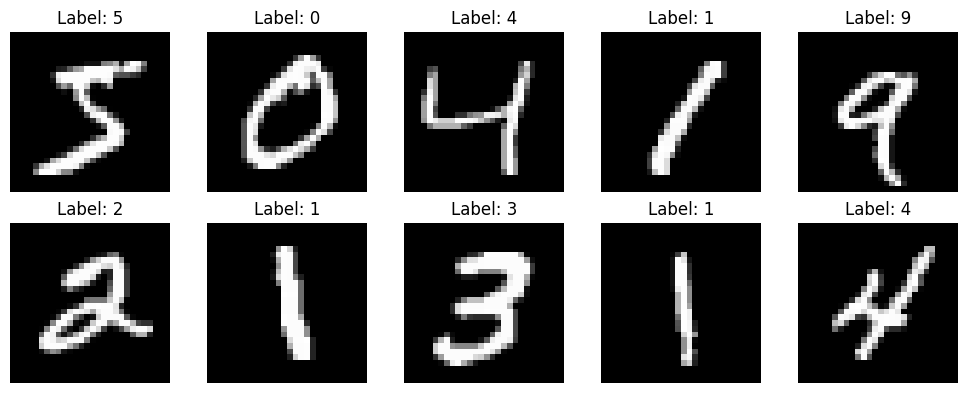

In [6]:
plt.figure(figsize=(10, 4))#创建一个10x4英寸的图形
for i in range(10):
    image, label = train_dataset[i]#获取第i个图像和标签
    plt.subplot(2, 5, i+1)#创建2行5列的子图
    plt.imshow(train_dataset[i][0].squeeze(), cmap='gray')#显示图像，去掉通道维度，并使用灰度颜色映射
    plt.title(f"Label: {train_dataset[i][1]}")
    plt.axis('off')
plt.tight_layout()#调整子图之间的间距
plt.show()

In [7]:
batch_size = 128 #定义批量大小

train_size=54000
val_size=6000
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)#设置随机种子以确保结果可复现
    )

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {len(train_subset)}样本")
print(f"验证集大小: {len(val_subset)}样本")
print(f"测试集大小: {len(test_dataset)}样本")
print(f"训练批次数: {len(train_loader)}")
print(f"验证批次数: {len(val_loader)}")
print(f"测试批次数: {len(test_loader)}")
print(f"每批次大小: {batch_size}")




训练集大小: 54000样本
验证集大小: 6000样本
测试集大小: 10000样本
训练批次数: 422
验证批次数: 47
测试批次数: 79
每批次大小: 128


In [8]:
# 定义一个简单的卷积神经网络
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()#将输入展平为一维
        self.fc1 = nn.Linear(28*28, 128)#第一个全连接层，将输入从784维映射到128维
        self.fc2 = nn.Linear(128, 64)#第二个全连接层，将输入从128维映射到64维
        self.fc3 = nn.Linear(64, 10)#第三个全连接层，将输入从64维映射到10维（对应10个类别）
        self.relu = nn.ReLU()#ReLU激活函数


    def forward(self, x):
        x = self.flatten(x)#展平输入
        x = self.fc1(x)#通过第一个全连接层
        x = self.relu(x)#应用ReLU激活函数
        x = self.fc2(x)#通过第二个全连接层
        x = self.relu(x)#应用ReLU激活函数
        x = self.fc3(x)#通过第三个全连接层
        return x
model = MLP().to(device)#将模型移动到GPU（如果可用）

print(model)
print(f"模型参数总数： {sum(p.numel() for p in model.parameters())}")



MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)
模型参数总数： 109386


In [9]:
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()#定义损失函数为交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.001)#定义优化器为Adam，



In [11]:
#训练模型
num_epochs = 10 #定义训练的轮数

history = {
    'step': [],
    'train_loss_steps': [],
    'epochs': [],
    'val_loss_epochs': [],
    'val_acc_epochs': []
}

print("开始训练...")
print("-"*50)
global_step = 0

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)#将数据移动到GPU（如果可用）
        
        outputs = model(images)#前向传播
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()#清除之前的梯度
        loss.backward()#反向传播
        optimizer.step()#更新模型参数
        
        history['step'].append(global_step)
        history['train_loss_steps'].append(loss.item())
        
        epoch_train_loss += loss.item()
        global_step += 1
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    
    # 验证模型
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()#累计验证损失
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total

    # 记录验证结果
    history['epochs'].append(epoch)
    history['val_loss_epochs'].append(avg_val_loss)
    history['val_acc_epochs'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print("-"*50)
    print("训练完成！")

开始训练...
--------------------------------------------------
Epoch [1/10] - Train Loss: 0.4507, Val Loss: 0.2498, Val Acc: 92.50%
--------------------------------------------------
训练完成！
Epoch [2/10] - Train Loss: 0.1879, Val Loss: 0.1752, Val Acc: 94.82%
--------------------------------------------------
训练完成！
Epoch [3/10] - Train Loss: 0.1310, Val Loss: 0.1377, Val Acc: 95.58%
--------------------------------------------------
训练完成！
Epoch [4/10] - Train Loss: 0.0972, Val Loss: 0.1210, Val Acc: 96.58%
--------------------------------------------------
训练完成！
Epoch [5/10] - Train Loss: 0.0766, Val Loss: 0.1088, Val Acc: 96.62%
--------------------------------------------------
训练完成！
Epoch [6/10] - Train Loss: 0.0620, Val Loss: 0.0940, Val Acc: 97.20%
--------------------------------------------------
训练完成！
Epoch [7/10] - Train Loss: 0.0500, Val Loss: 0.0882, Val Acc: 97.33%
--------------------------------------------------
训练完成！
Epoch [8/10] - Train Loss: 0.0410, Val Loss: 0.0877, Val Ac

In [12]:
print(f"训练完成！总共{global_step}个训练步")

训练完成！总共4220个训练步


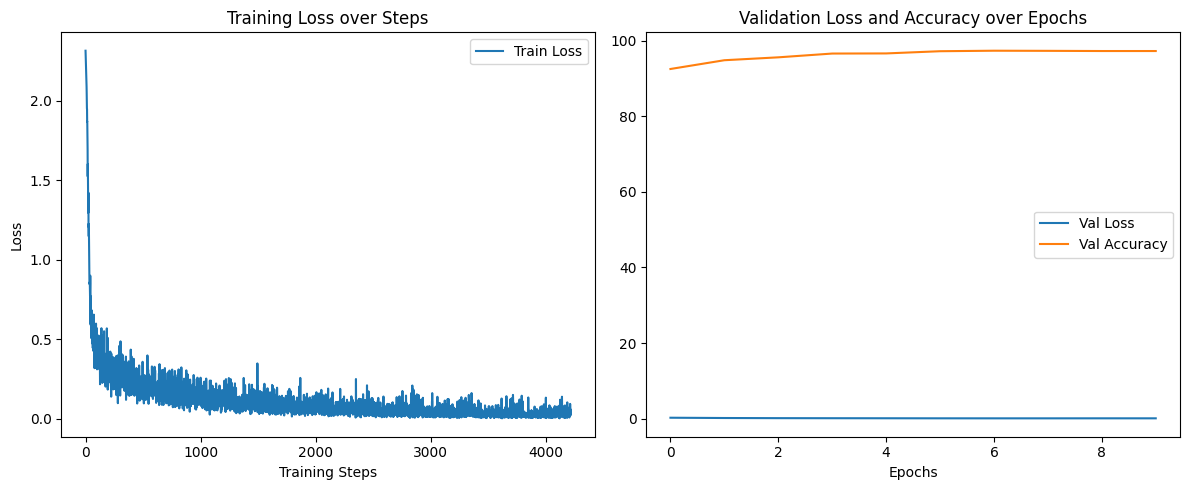

In [13]:
#可视化训练过程
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['step'], history['train_loss_steps'], label='Train Loss')  
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['epochs'], history['val_loss_epochs'], label='Val Loss')
plt.plot(history['epochs'], history['val_acc_epochs'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.title('Validation Loss and Accuracy over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
#在测试集上评估模型
print("="*50)
print("在测试集上评估模型...")
print("="*50)

model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

final_test_loss = test_loss / len(test_loader)
final_test_acc = 100. * test_correct / test_total

print(f"测试集上的平均损失: {final_test_loss:.4f}, 测试集上的准确率: {final_test_acc:.2f}%")
print(f"对比最佳验证准确率: {max(history['val_acc_epochs']):.2f}%")

print("="*50)




在测试集上评估模型...
测试集上的平均损失: 0.0815, 测试集上的准确率: 97.61%
对比最佳验证准确率: 97.33%


<Figure size 1000x400 with 0 Axes>

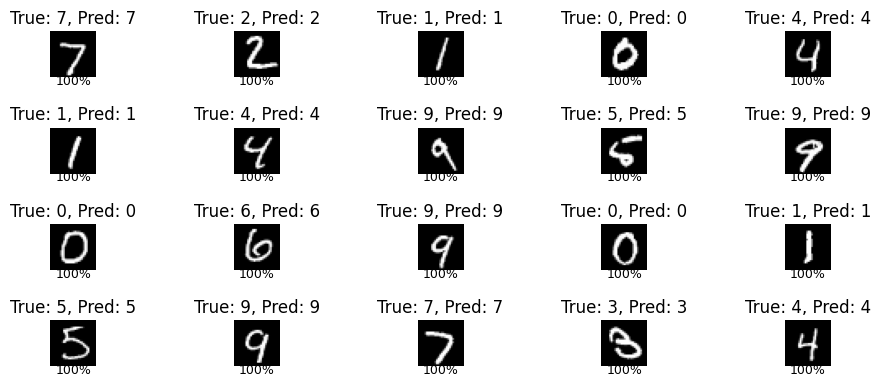

In [21]:
# 可视化预测结果（展示前20张测试图像的预测结果）
model.eval()
plt.figure(figsize=(10, 4))

fig, axes = plt.subplots(4, 5, figsize=(10, 4))
with torch.no_grad():
    for i in range(20):
        image, label = test_dataset[i]
        image_input = image.unsqueeze(0).to(device)
        output = model(image_input)
        _, predicted = torch.max(output.data, 1)
        acc_text = "100%" if predicted.item() == label else "0%"

        ax = axes[i // 5, i % 5]
        ax.imshow(image.squeeze(), cmap='gray')
        ax.set_title(f"True: {label}, Pred: {predicted.item()}")
        ax.text(0.5, -0.15, acc_text, size=9, ha='center', transform=ax.transAxes)
        ax.axis('off')

plt.tight_layout()
plt.show()